# Happy Path Discovery - BPI Challenge 2017

Notebook này xây dựng happy path theo hướng nghiệp vụ, không chỉ lấy top variant thô.

## Mục tiêu
- Xác định case "thành công" theo outcome nghiệp vụ.
- Trích xuất happy path có độ phủ cao nhưng vẫn đảm bảo thời gian xử lý tốt.
- Sinh bảng KPI theo từng bước để giải thích luồng và điểm tách nhánh.

## Ý tưởng thuật toán
1. Chuẩn hóa log theo `case`, `activity`, `timestamp`, ưu tiên sự kiện `complete`.
2. Định nghĩa **successful case**: có `A_Accepted` và không có `A_Cancelled` / `A_Denied`.
3. Gom trace variant trên tập successful.
4. Chấm điểm variant bằng hỗn hợp:
   - Độ phủ (frequency) cao.
   - Thời gian hoàn tất (median duration) thấp.
5. Lấy variant điểm cao nhất làm happy path và tính KPI chờ theo từng bước.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

plt.style.use("seaborn-v0_8-whitegrid")

DATA_PATH = Path("../data/bpi-challenge-2017/bpi_2017_cleaned.csv")
OUT_DIR = Path("../results/happy_path")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Data path:", DATA_PATH)
print("Output dir:", OUT_DIR)

Data path: ..\data\bpi-challenge-2017\bpi_2017_cleaned.csv
Output dir: ..\results\happy_path


In [2]:
# 1) Load and normalize log
use_cols = [
    "case:concept:name",
    "concept:name",
    "lifecycle:transition",
    "time:timestamp",
    "case:ApplicationType",
    "Accepted",
]

raw = pd.read_csv(DATA_PATH, usecols=use_cols)
raw["time:timestamp"] = pd.to_datetime(raw["time:timestamp"], errors="coerce")
raw = raw.dropna(subset=["time:timestamp"]).copy()

# Keep complete transitions for stable control-flow discovery
log_df = raw[raw["lifecycle:transition"].eq("complete")].copy()
log_df = log_df.sort_values(["case:concept:name", "time:timestamp"]).reset_index(drop=True)

# Normalize activity naming for easier business interpretation
log_df["activity_norm"] = (
    log_df["concept:name"]
    .str.replace("O_Sent \(mail and online\)", "O_Sent", regex=True)
    .str.replace("O_Sent \(online only\)", "O_Sent", regex=True)
)

print("Total complete events:", len(log_df))
print("Total cases:", log_df["case:concept:name"].nunique())
print("Top activities:")
print(log_df["activity_norm"].value_counts().head(15))

<>:22: SyntaxWarning: invalid escape sequence '\('
<>:23: SyntaxWarning: invalid escape sequence '\('
<>:22: SyntaxWarning: invalid escape sequence '\('
<>:23: SyntaxWarning: invalid escape sequence '\('
C:\Users\Admin\AppData\Local\Temp\ipykernel_820\2233069353.py:22: SyntaxWarning: invalid escape sequence '\('
  .str.replace("O_Sent \(mail and online\)", "O_Sent", regex=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_820\2233069353.py:23: SyntaxWarning: invalid escape sequence '\('
  .str.replace("O_Sent \(online only\)", "O_Sent", regex=True)


Total complete events: 474843
Total cases: 31509
Top activities:
activity_norm
O_Created                 42957
O_Create Offer            42952
O_Sent                    41689
A_Validating              38779
A_Concept                 31486
A_Create Application      31481
A_Accepted                31480
A_Complete                31337
O_Returned                23282
A_Incomplete              23036
O_Cancelled               20878
A_Submitted               20397
W_Complete application    19088
O_Accepted                17210
A_Pending                 17206
Name: count, dtype: int64


In [3]:
# 2) Build trace table and define successful cases
trace_df = (
    log_df.groupby("case:concept:name")
    .agg(
        trace=("activity_norm", lambda x: tuple(x.tolist())),
        start_time=("time:timestamp", "min"),
        end_time=("time:timestamp", "max"),
        app_type=("case:ApplicationType", "first"),
    )
    .reset_index()
)
trace_df["duration_hours"] = (trace_df["end_time"] - trace_df["start_time"]).dt.total_seconds() / 3600

# Successful = accepted and not denied/cancelled
trace_df["has_accepted"] = trace_df["trace"].apply(lambda t: "A_Accepted" in t)
trace_df["has_denied"] = trace_df["trace"].apply(lambda t: "A_Denied" in t)
trace_df["has_cancelled"] = trace_df["trace"].apply(lambda t: "A_Cancelled" in t)
trace_df["is_success"] = trace_df["has_accepted"] & (~trace_df["has_denied"]) & (~trace_df["has_cancelled"])

success_df = trace_df[trace_df["is_success"]].copy()

print("Total traces:", len(trace_df))
print("Successful traces:", len(success_df))
print("Success rate (%):", round(len(success_df) / max(len(trace_df), 1) * 100, 2))

Total traces: 31509
Successful traces: 17320
Success rate (%): 54.97


In [4]:
# 3) Rank variants by business score: high coverage + short duration
variant_stats = (
    success_df.groupby("trace")
    .agg(
        cases=("case:concept:name", "count"),
        median_duration_h=("duration_hours", "median"),
        mean_duration_h=("duration_hours", "mean"),
    )
    .reset_index()
)

variant_stats["coverage"] = variant_stats["cases"] / variant_stats["cases"].sum()

# Normalize duration so lower is better
min_d = variant_stats["median_duration_h"].min()
max_d = variant_stats["median_duration_h"].max()
if max_d > min_d:
    variant_stats["duration_score"] = 1 - (variant_stats["median_duration_h"] - min_d) / (max_d - min_d)
else:
    variant_stats["duration_score"] = 1.0

# Weighted objective for happy path
variant_stats["happy_score"] = 0.7 * variant_stats["coverage"] + 0.3 * variant_stats["duration_score"]
variant_stats = variant_stats.sort_values(["happy_score", "cases"], ascending=False).reset_index(drop=True)

happy_trace = variant_stats.loc[0, "trace"]
happy_len = len(happy_trace)

print("Happy path length:", happy_len)
print("Happy path:")
print(" -> ".join(happy_trace))

print("\nTop 10 candidate variants:")
print(variant_stats.head(10)[["cases", "coverage", "median_duration_h", "happy_score"]])

variant_stats.head(30).to_csv(OUT_DIR / "variant_ranking.csv", index=False)

Happy path length: 12
Happy path:
A_Create Application -> A_Concept -> A_Accepted -> O_Create Offer -> O_Created -> O_Sent -> W_Complete application -> A_Complete -> A_Validating -> O_Returned -> O_Accepted -> A_Pending

Top 10 candidate variants:
   cases  coverage  median_duration_h  happy_score
0    971  0.056062         237.604511     0.317987
1    667  0.038510         262.922098     0.303433
2    613  0.035393         260.676237     0.301452
3      8  0.000462           0.458700     0.300306
4      6  0.000346           1.114911     0.300166
5      5  0.000289           1.658664     0.300077
6      1  0.000058           0.264146     0.300040
7      1  0.000058           1.500774     0.299930
8      1  0.000058           5.954701     0.299531
9      1  0.000058          24.244530     0.297893


In [5]:
# 4) Step-level KPI on happy-path-aligned traces

def is_subsequence(path, trace):
    it = iter(trace)
    return all(step in it for step in path)

happy_aligned = success_df[success_df["trace"].apply(lambda t: is_subsequence(happy_trace, t))].copy()
print("Happy-aligned successful cases:", len(happy_aligned))

happy_case_ids = set(happy_aligned["case:concept:name"])
happy_events = log_df[log_df["case:concept:name"].isin(happy_case_ids)].copy()

# Keep only events that are in happy path and preserve order
happy_order = {a: i for i, a in enumerate(happy_trace)}
happy_events = happy_events[happy_events["activity_norm"].isin(happy_order)].copy()
happy_events["step_idx"] = happy_events["activity_norm"].map(happy_order)

# First occurrence timestamp per step in each case
step_time = (
    happy_events.sort_values(["case:concept:name", "time:timestamp"])
    .groupby(["case:concept:name", "activity_norm"], as_index=False)
    .first()[["case:concept:name", "activity_norm", "time:timestamp", "step_idx"]]
)

step_time = step_time.sort_values(["case:concept:name", "step_idx"]).copy()
step_time["next_activity"] = step_time.groupby("case:concept:name")["activity_norm"].shift(-1)
step_time["next_time"] = step_time.groupby("case:concept:name")["time:timestamp"].shift(-1)
step_time["wait_minutes"] = (step_time["next_time"] - step_time["time:timestamp"]).dt.total_seconds() / 60

edge_kpi = (
    step_time.dropna(subset=["next_activity", "wait_minutes"])
    .assign(edge=lambda d: d["activity_norm"] + " -> " + d["next_activity"])
    .groupby("edge")
    .agg(
        cases=("wait_minutes", "size"),
        mean_wait_min=("wait_minutes", "mean"),
        median_wait_min=("wait_minutes", "median"),
        p90_wait_min=("wait_minutes", lambda s: s.quantile(0.9)),
    )
    .sort_values("p90_wait_min", ascending=False)
    .reset_index()
)

print("\nTop edges by P90 waiting time:")
print(edge_kpi.head(15))

edge_kpi.to_csv(OUT_DIR / "happy_path_edge_kpi.csv", index=False)

Happy-aligned successful cases: 10318

Top edges by P90 waiting time:
                                    edge  cases  mean_wait_min  \
0             A_Complete -> A_Validating  10318   13923.618620   
1               O_Returned -> O_Accepted  10318    9963.431807   
2                A_Concept -> A_Accepted  10318    1045.484454   
3           A_Accepted -> O_Create Offer  10318      76.809799   
4             A_Validating -> O_Returned  10318     243.182885   
5                    O_Created -> O_Sent  10318      25.857002   
6      A_Create Application -> A_Concept  10318      22.926914   
7            O_Create Offer -> O_Created  10318       0.017517   
8       O_Sent -> W_Complete application  10318      -2.277300   
9   W_Complete application -> A_Complete  10318       2.278038   
10               O_Accepted -> A_Pending  10318       0.000138   

    median_wait_min  p90_wait_min  
0      11096.317775  25664.417948  
1       7095.950200  24243.821947  
2         41.405417   2891.12

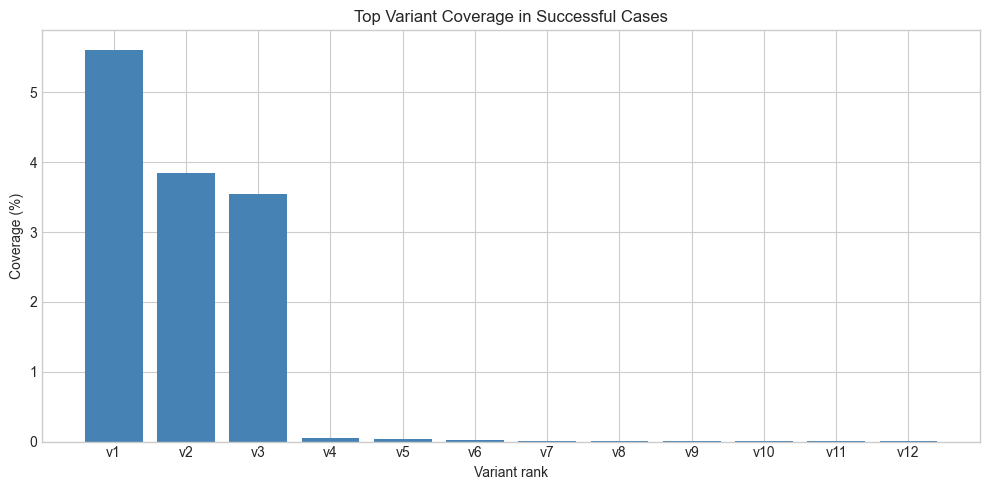

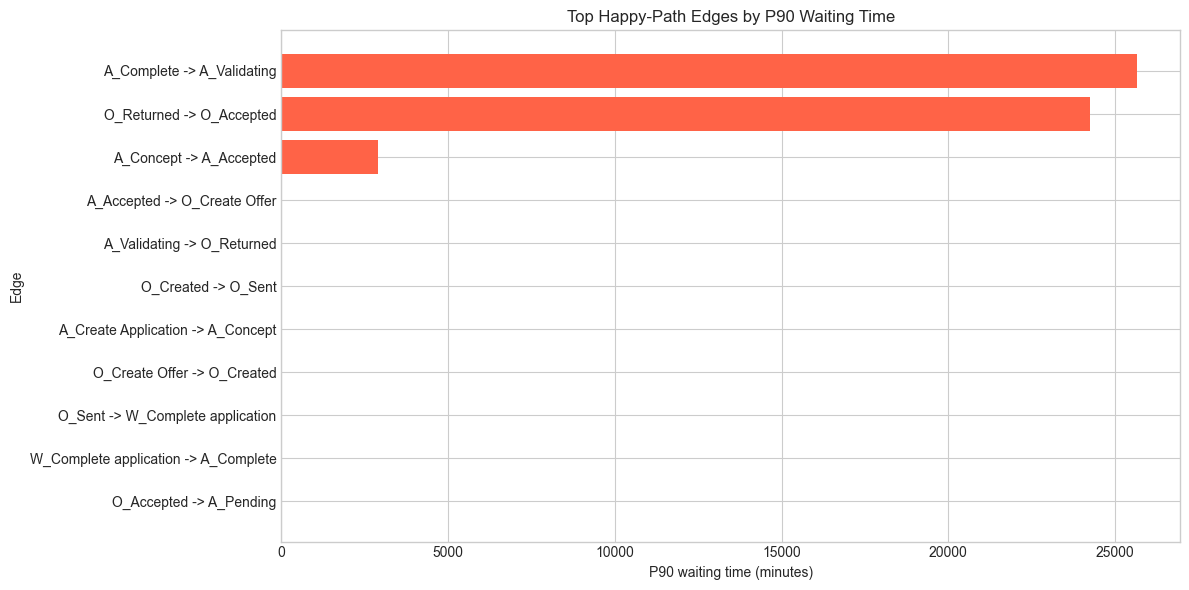

In [6]:
# 5) Lightweight visualization (without full DFG clutter)

# (a) Variant coverage chart
fig, ax = plt.subplots(figsize=(10, 5))
plot_vs = variant_stats.head(12).copy()
plot_vs["label"] = [f"v{i+1}" for i in range(len(plot_vs))]
ax.bar(plot_vs["label"], plot_vs["coverage"] * 100, color="steelblue")
ax.set_title("Top Variant Coverage in Successful Cases")
ax.set_xlabel("Variant rank")
ax.set_ylabel("Coverage (%)")
plt.tight_layout()
plt.show()

# (b) Happy-path edge wait chart
fig, ax = plt.subplots(figsize=(12, 6))
plot_edge = edge_kpi.head(12).iloc[::-1]
ax.barh(plot_edge["edge"], plot_edge["p90_wait_min"], color="tomato")
ax.set_title("Top Happy-Path Edges by P90 Waiting Time")
ax.set_xlabel("P90 waiting time (minutes)")
ax.set_ylabel("Edge")
plt.tight_layout()
plt.show()

In [7]:
# 6) Business interpretation table

def map_business_phase(activity: str) -> str:
    if activity in {"A_Create Application", "A_Submitted", "W_Handle leads", "W_Complete application", "A_Concept"}:
        return "Intake"
    if activity in {"A_Accepted", "A_Denied", "A_Pending", "W_Validate application", "A_Validating"}:
        return "Risk/Decision"
    if activity.startswith("O_") or activity in {"W_Call after offers", "A_Complete"}:
        return "Offer/Closure"
    if activity in {"W_Call incomplete files", "A_Incomplete"}:
        return "Rework"
    return "Other"

happy_path_df = pd.DataFrame({
    "step_order": list(range(1, len(happy_trace) + 1)),
    "activity": list(happy_trace),
})
happy_path_df["business_phase"] = happy_path_df["activity"].map(map_business_phase)

print("Happy path table:")
print(happy_path_df)

happy_path_df.to_csv(OUT_DIR / "happy_path_steps.csv", index=False)

print("\nSaved artifacts:")
print(OUT_DIR / "variant_ranking.csv")
print(OUT_DIR / "happy_path_edge_kpi.csv")
print(OUT_DIR / "happy_path_steps.csv")

Happy path table:
    step_order                activity business_phase
0            1    A_Create Application         Intake
1            2               A_Concept         Intake
2            3              A_Accepted  Risk/Decision
3            4          O_Create Offer  Offer/Closure
4            5               O_Created  Offer/Closure
5            6                  O_Sent  Offer/Closure
6            7  W_Complete application         Intake
7            8              A_Complete  Offer/Closure
8            9            A_Validating  Risk/Decision
9           10              O_Returned  Offer/Closure
10          11              O_Accepted  Offer/Closure
11          12               A_Pending  Risk/Decision

Saved artifacts:
..\results\happy_path\variant_ranking.csv
..\results\happy_path\happy_path_edge_kpi.csv
..\results\happy_path\happy_path_steps.csv


## DFG Tách Riêng Cho Từng Happy Path

Phần này xuất DFG độc lập cho:
- Top-N happy paths trên toàn bộ successful cases.
- Happy path tốt nhất cho từng `case:ApplicationType`.

Mỗi DFG được lưu ra file PNG riêng để đọc dễ và đưa vào báo cáo.

In [8]:
from graphviz import Digraph

DFG_DIR = OUT_DIR / "dfg_per_happy_path"
DFG_DIR.mkdir(parents=True, exist_ok=True)


def shorten(name: str) -> str:
    return (
        name.replace("Application", "App")
        .replace("complete", "cpl")
        .replace("Accepted", "Acc")
        .replace("Cancelled", "Canc")
    )


def dfg_from_trace(trace, trace_cases: int):
    edges = Counter()
    for i in range(len(trace) - 1):
        edges[(trace[i], trace[i + 1])] += trace_cases
    return edges


def draw_dfg_from_trace(trace, trace_cases: int, title: str, out_file_no_ext: Path):
    edges = dfg_from_trace(trace, trace_cases)
    dot = Digraph(comment=title)
    dot.attr(rankdir="LR", nodesep="0.5", ranksep="0.8", fontsize="12")

    nodes = set([n for e in edges.keys() for n in e])
    for n in nodes:
        dot.node(n, shorten(n), shape="box", style="rounded,filled", fillcolor="#f8fbff")

    for (src, tgt), freq in edges.items():
        dot.edge(src, tgt, label=str(freq), penwidth=str(1 + min(freq / 200, 4)))

    dot.render(str(out_file_no_ext), format="png", cleanup=True)


# A) Top-N happy paths globally
TOP_N = 5
top_happy = variant_stats.head(TOP_N).copy()
export_rows = []

for i, row in top_happy.iterrows():
    trace = row["trace"]
    cases = int(row["cases"])
    cov = float(row["coverage"])
    score = float(row["happy_score"])

    file_base = DFG_DIR / f"happy_path_global_{i+1:02d}"
    title = f"Global Happy Path #{i+1} | cases={cases}, cov={cov:.2%}, score={score:.3f}"
    draw_dfg_from_trace(trace, cases, title, file_base)

    export_rows.append({
        "scope": "global",
        "rank": i + 1,
        "application_type": "ALL",
        "cases": cases,
        "coverage": cov,
        "happy_score": score,
        "trace": " -> ".join(trace),
        "dfg_png": str(file_base.with_suffix(".png")),
    })


# B) Best happy path per application type
for app_type, group in success_df.groupby("app_type"):
    by_variant = (
        group.groupby("trace")
        .agg(
            cases=("case:concept:name", "count"),
            median_duration_h=("duration_hours", "median"),
        )
        .reset_index()
    )
    by_variant["coverage"] = by_variant["cases"] / by_variant["cases"].sum()

    min_d = by_variant["median_duration_h"].min()
    max_d = by_variant["median_duration_h"].max()
    if max_d > min_d:
        by_variant["duration_score"] = 1 - (by_variant["median_duration_h"] - min_d) / (max_d - min_d)
    else:
        by_variant["duration_score"] = 1.0

    by_variant["happy_score"] = 0.7 * by_variant["coverage"] + 0.3 * by_variant["duration_score"]
    by_variant = by_variant.sort_values(["happy_score", "cases"], ascending=False).reset_index(drop=True)

    best = by_variant.loc[0]
    trace = best["trace"]
    cases = int(best["cases"])
    cov = float(best["coverage"])
    score = float(best["happy_score"])

    safe_app = str(app_type).replace(" ", "_").replace("/", "_")
    file_base = DFG_DIR / f"happy_path_{safe_app}"
    title = f"Happy Path | {app_type} | cases={cases}, cov={cov:.2%}, score={score:.3f}"
    draw_dfg_from_trace(trace, cases, title, file_base)

    export_rows.append({
        "scope": "application_type",
        "rank": 1,
        "application_type": app_type,
        "cases": cases,
        "coverage": cov,
        "happy_score": score,
        "trace": " -> ".join(trace),
        "dfg_png": str(file_base.with_suffix(".png")),
    })

export_df = pd.DataFrame(export_rows)
export_df.to_csv(DFG_DIR / "happy_path_dfg_index.csv", index=False)

print("Generated DFG files:")
print(export_df[["scope", "rank", "application_type", "cases", "coverage", "happy_score", "dfg_png"]])
print("\nIndex file:", DFG_DIR / "happy_path_dfg_index.csv")

Generated DFG files:
              scope  rank application_type  cases  coverage  happy_score  \
0            global     1              ALL    971  0.056062     0.317987   
1            global     2              ALL    667  0.038510     0.303433   
2            global     3              ALL    613  0.035393     0.301452   
3            global     4              ALL      8  0.000462     0.300306   
4            global     5              ALL      6  0.000346     0.300166   
5  application_type     1      Limit raise    491  0.197586     0.414867   
6  application_type     1       New credit    667  0.044961     0.307980   

                                             dfg_png  
0  ..\results\happy_path\dfg_per_happy_path\happy...  
1  ..\results\happy_path\dfg_per_happy_path\happy...  
2  ..\results\happy_path\dfg_per_happy_path\happy...  
3  ..\results\happy_path\dfg_per_happy_path\happy...  
4  ..\results\happy_path\dfg_per_happy_path\happy...  
5  ..\results\happy_path\dfg_per_happy_p

## Next Steps: Conformance + Root-Cause + Action Plan

Phần này chuyển từ "vẽ process" sang "đo lường và ưu tiên cải tiến":

1. Tính độ lệch của từng trace so với happy path (conformance proxy).
2. So sánh nhóm `success` và `non-success` để tìm yếu tố gây lệch.
3. Khai thác root-cause theo `ApplicationType` và `LoanGoal`.
4. Xuất bảng hành động ưu tiên cho giai đoạn Data Mining / Process Mining tiếp theo.

In [9]:
# 7) Conformance proxy against happy path (sequence distance)

def levenshtein_distance(seq_a, seq_b):
    la, lb = len(seq_a), len(seq_b)
    dp = [[0] * (lb + 1) for _ in range(la + 1)]

    for i in range(la + 1):
        dp[i][0] = i
    for j in range(lb + 1):
        dp[0][j] = j

    for i in range(1, la + 1):
        for j in range(1, lb + 1):
            cost = 0 if seq_a[i - 1] == seq_b[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,      # deletion
                dp[i][j - 1] + 1,      # insertion
                dp[i - 1][j - 1] + cost,  # substitution
            )
    return dp[la][lb]


def count_rework(trace):
    rework_set = {"W_Call incomplete files", "A_Incomplete", "W_Validate application"}
    return sum(1 for x in trace if x in rework_set)

analysis_df = trace_df.copy()
analysis_df["edit_distance"] = analysis_df["trace"].apply(lambda t: levenshtein_distance(t, happy_trace))
analysis_df["norm_distance"] = analysis_df["edit_distance"] / analysis_df["trace"].apply(lambda t: max(len(t), len(happy_trace), 1))
analysis_df["rework_events"] = analysis_df["trace"].apply(count_rework)
analysis_df["trace_len"] = analysis_df["trace"].apply(len)
analysis_df["is_non_success"] = ~analysis_df["is_success"]

# Deviation label for prioritization
analysis_df["deviation_band"] = pd.cut(
    analysis_df["norm_distance"],
    bins=[-1, 0.2, 0.4, 0.6, 1.0],
    labels=["low", "medium", "high", "very_high"],
)

print("Conformance snapshot (Success vs Non-success):")
summary = analysis_df.groupby("is_success").agg(
    cases=("case:concept:name", "count"),
    median_norm_distance=("norm_distance", "median"),
    p90_norm_distance=("norm_distance", lambda s: s.quantile(0.9)),
    median_rework=("rework_events", "median"),
    median_duration_h=("duration_hours", "median"),
)
print(summary)

print("\nDeviation band distribution (%):")
band_dist = (
    analysis_df.groupby(["is_success", "deviation_band"]).size().rename("cases").reset_index()
)
band_dist["pct"] = band_dist.groupby("is_success")["cases"].transform(lambda s: s / s.sum() * 100)
print(band_dist.sort_values(["is_success", "deviation_band"]))

analysis_df.to_csv(OUT_DIR / "conformance_case_metrics.csv", index=False)
print("\nSaved:", OUT_DIR / "conformance_case_metrics.csv")

Conformance snapshot (Success vs Non-success):
            cases  median_norm_distance  p90_norm_distance  median_rework  \
is_success                                                                  
False       14189              0.428571           0.583333            0.0   
True        17320              0.285714           0.520000            1.0   

            median_duration_h  
is_success                     
False              740.302054  
True               356.011850  

Deviation band distribution (%):
   is_success deviation_band  cases        pct
0       False            low    171   1.205159
1       False         medium   3818  26.908168
2       False           high   9526  67.136514
3       False      very_high    674   4.750159
4        True            low   5952  34.364896
5        True         medium   7010  40.473441
6        True           high   3883  22.419169
7        True      very_high    475   2.742494


C:\Users\Admin\AppData\Local\Temp\ipykernel_820\2473457165.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df.groupby(["is_success", "deviation_band"]).size().rename("cases").reset_index()



Saved: ..\results\happy_path\conformance_case_metrics.csv


In [12]:
# 8) Root-cause mining by business attributes + actionable plan

# Ensure a clean LoanGoal column before enrichment (handles reruns safely)
loan_cols = [c for c in analysis_df.columns if c.startswith("case:LoanGoal")]
if loan_cols:
    analysis_df = analysis_df.drop(columns=loan_cols)

# Enrich LoanGoal per case (if available in dataset)
try:
    loan_goal_df = pd.read_csv(
        DATA_PATH,
        usecols=["case:concept:name", "case:LoanGoal"],
    ).drop_duplicates(subset=["case:concept:name"])
    analysis_df = analysis_df.merge(loan_goal_df, on="case:concept:name", how="left")
except Exception:
    analysis_df["case:LoanGoal"] = np.nan

root_metrics = analysis_df.groupby("app_type").agg(
    cases=("case:concept:name", "count"),
    non_success_rate=("is_non_success", "mean"),
    median_norm_distance=("norm_distance", "median"),
    p90_norm_distance=("norm_distance", lambda s: s.quantile(0.9)),
    median_duration_h=("duration_hours", "median"),
    median_rework=("rework_events", "median"),
).reset_index().sort_values("non_success_rate", ascending=False)

print("Root-cause by ApplicationType:")
print(root_metrics)

loan_goal_metrics = (
    analysis_df.dropna(subset=["case:LoanGoal"]) 
    .groupby("case:LoanGoal")
    .agg(
        cases=("case:concept:name", "count"),
        non_success_rate=("is_non_success", "mean"),
        median_norm_distance=("norm_distance", "median"),
        median_duration_h=("duration_hours", "median"),
    )
    .reset_index()
)
loan_goal_metrics = loan_goal_metrics[loan_goal_metrics["cases"] >= 100].sort_values("non_success_rate", ascending=False)

print("\nRoot-cause by LoanGoal (cases >= 100):")
print(loan_goal_metrics.head(15))

# Build action plan from metrics
actions = []
for _, r in root_metrics.iterrows():
    if r["non_success_rate"] >= 0.45:
        risk = "high"
    elif r["non_success_rate"] >= 0.30:
        risk = "medium"
    else:
        risk = "low"

    if risk == "high":
        action = "Ưu tiên can thiệp sớm: tạo cảnh báo lệch happy path ở prefix 30-40%, gom cụm case đi vào nhánh offer/rework để xử lý trước"
    elif r["median_rework"] >= 3:
        action = "Giảm rework: chuẩn hóa checklist hồ sơ đầu vào và trigger nhắc thiếu chứng từ sớm"
    elif r["median_norm_distance"] >= 0.45:
        action = "Giảm lệch chuẩn: rà soát biến thể lệch nhiều nhất và chuẩn hóa handoff giữa các work item"
    else:
        action = "Duy trì vận hành: theo dõi drift định kỳ theo tuần và cảnh báo khi p90 tăng"

    actions.append({
        "segment": str(r["app_type"]),
        "risk_level": risk,
        "non_success_rate": round(float(r["non_success_rate"]), 4),
        "median_norm_distance": round(float(r["median_norm_distance"]), 4),
        "median_rework": round(float(r["median_rework"]), 2),
        "recommended_action": action,
    })

action_plan_df = pd.DataFrame(actions).sort_values(["non_success_rate"], ascending=[False])

print("\nAction plan by segment:")
print(action_plan_df)

root_metrics.to_csv(OUT_DIR / "root_cause_by_application_type.csv", index=False)
loan_goal_metrics.to_csv(OUT_DIR / "root_cause_by_loan_goal.csv", index=False)
action_plan_df.to_csv(OUT_DIR / "action_plan_by_segment.csv", index=False)

print("\nSaved:")
print(OUT_DIR / "root_cause_by_application_type.csv")
print(OUT_DIR / "root_cause_by_loan_goal.csv")
print(OUT_DIR / "action_plan_by_segment.csv")

Root-cause by ApplicationType:
      app_type  cases  non_success_rate  median_norm_distance  \
1   New credit  28120          0.472440              0.400000   
0  Limit raise   3389          0.266745              0.230769   

   p90_norm_distance  median_duration_h  median_rework  
1           0.571429         484.241349            1.0  
0           0.416667         332.810909            1.0  

Root-cause by LoanGoal (cases >= 100):
             case:LoanGoal  cases  non_success_rate  median_norm_distance  \
9            Not speficied   1065          0.583099              0.444444   
12            Tax payments    152          0.526316              0.371711   
8               Motorcycle    275          0.501818              0.400000   
10  Other, see explanation   2985          0.492127              0.375000   
2                      Car   9328          0.484670              0.400000   
6     Extra spending limit    625          0.468800              0.333333   
5   Existing loan takeo